#  Group 2 Sentiment Analysis: GRU Architecture with one to many ID to Contents

###  **DSBA 6165: AI & Deep Learning**
### Group Member: Paul Berlin, Anders Pierson, Roberto Panameno

## Proc2 Goal

Using the same model that was initially developed, apply the model to a dataset that has been concatenated so that there is 1 comment per ID. This will make the text entries much longer.

## Uploading Training and Validation Dataset

In [ ]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Importing Dataset
datatot = pd.read_csv('/content/twitter_combined.csv')

In [ ]:
datatot.head(5)

,tweet_id,entity,sentiment,tweet_content
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


## Data Preprocessing

In [ ]:
import re
import pandas as pd # Ensure pandas is available, though it's likely already loaded

def clean_text(text):
    text = str(text) # Ensure the input is a string
    text = text.lower() # Convert text to lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'@\w+', '', text) # Remove user mentions
    text = re.sub(r'#\w+', '', text) # Remove hashtags
    text = re.sub(r'[^a-z\s]', '', text) # Remove special characters, keeping only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip() # Replace multiple spaces with a single space and strip leading/trailing spaces
    return text

# Group by tweet_id and other relevant identifiers (entity, sentiment) and concatenate the original 'tweet_content' for each unique group.
grouped_datatot = datatot.groupby(['tweet_id', 'entity', 'sentiment'])['tweet_content'].apply(lambda x: ' '.join(x.astype(str))).reset_index()

# Apply the clean_text function to the newly concatenated 'tweet_content'
grouped_datatot['cleaned_tweet_content'] = grouped_datatot['tweet_content'].apply(clean_text)

# Replace the original datatot DataFrame with this new, grouped and cleaned version.
datatot = grouped_datatot

print("Text cleaning and concatenation complete. Dataframe now grouped by 'tweet_id'.")
print("Displaying the first 5 rows with the new 'cleaned_tweet_content' column:")
datatot.head()

Text cleaning and concatenation complete. Dataframe now grouped by 'tweet_id'.
Displaying the first 5 rows with the new 'cleaned_tweet_content' column:


,tweet_id,entity,sentiment,tweet_content,cleaned_tweet_content
0,1,Amazon,Negative,@amazon wtf . @ amazon wtf. @ amazon wtf. @am...,wtf amazon wtf amazon wtf wtf wtf unk wtf
1,2,Amazon,Negative,I’m really disappointed with amazon today! I o...,im really disappointed with amazon today i ord...
2,3,Amazon,Neutral,"Admit it subs, you leak over the thought of a ...",admit it subs you leak over the thought of a c...
3,4,Amazon,Negative,@amazon probably some of the worst customer se...,probably some of the worst customer service iv...
4,5,Amazon,Irrelevant,"I've purchased 10 times on her site, 2 times o...",ive purchased times on her site times on itune...


## Tokenize Text

In [ ]:
datatot['tokenized_tweet_content'] = datatot['cleaned_tweet_content'].apply(lambda x: x.split())

print("Text tokenization complete. Displaying the first 5 rows with the new 'tokenized_tweet_content' column:")
datatot.head()

Text tokenization complete. Displaying the first 5 rows with the new 'tokenized_tweet_content' column:


,tweet_id,entity,sentiment,tweet_content,cleaned_tweet_content,tokenized_tweet_content
0,1,Amazon,Negative,@amazon wtf . @ amazon wtf. @ amazon wtf. @am...,wtf amazon wtf amazon wtf wtf wtf unk wtf,"[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,..."
1,2,Amazon,Negative,I’m really disappointed with amazon today! I o...,im really disappointed with amazon today i ord...,"[im, really, disappointed, with, amazon, today..."
2,3,Amazon,Neutral,"Admit it subs, you leak over the thought of a ...",admit it subs you leak over the thought of a c...,"[admit, it, subs, you, leak, over, the, though..."
3,4,Amazon,Negative,@amazon probably some of the worst customer se...,probably some of the worst customer service iv...,"[probably, some, of, the, worst, customer, ser..."
4,5,Amazon,Irrelevant,"I've purchased 10 times on her site, 2 times o...",ive purchased times on her site times on itune...,"[ive, purchased, times, on, her, site, times, ..."


## Remove Stopwords

In [ ]:
import nltk
nltk.download('stopwords')
print("NLTK stopwords corpus downloaded.")

NLTK stopwords corpus downloaded.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [word for word in tokens if word not in stop_words]

datatot['filtered_tweet_content'] = datatot['tokenized_tweet_content'].apply(remove_stopwords)

print("Stopword removal complete. Displaying the first 5 rows with the new 'filtered_tweet_content' column:")
datatot.head()

Stopword removal complete. Displaying the first 5 rows with the new 'filtered_tweet_content' column:


,tweet_id,entity,sentiment,tweet_content,cleaned_tweet_content,tokenized_tweet_content,filtered_tweet_content
0,1,Amazon,Negative,@amazon wtf . @ amazon wtf. @ amazon wtf. @am...,wtf amazon wtf amazon wtf wtf wtf unk wtf,"[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...","[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,..."
1,2,Amazon,Negative,I’m really disappointed with amazon today! I o...,im really disappointed with amazon today i ord...,"[im, really, disappointed, with, amazon, today...","[im, really, disappointed, amazon, today, orde..."
2,3,Amazon,Neutral,"Admit it subs, you leak over the thought of a ...",admit it subs you leak over the thought of a c...,"[admit, it, subs, you, leak, over, the, though...","[admit, subs, leak, thought, cheeky, hot, lad,..."
3,4,Amazon,Negative,@amazon probably some of the worst customer se...,probably some of the worst customer service iv...,"[probably, some, of, the, worst, customer, ser...","[probably, worst, customer, service, ive, deal..."
4,5,Amazon,Irrelevant,"I've purchased 10 times on her site, 2 times o...",ive purchased times on her site times on itune...,"[ive, purchased, times, on, her, site, times, ...","[ive, purchased, times, site, times, itunes, t..."


## Lemmatize Text

In [ ]:
import nltk
nltk.download('wordnet')
nltk.download('omw-1.4')
print("NLTK 'wordnet' and 'omw-1.4' corpora downloaded.")

NLTK 'wordnet' and 'omw-1.4' corpora downloaded.


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

datatot['lemmatized_tweet_content'] = datatot['filtered_tweet_content'].apply(lemmatize_tokens)

print("Lemmatization complete. Displaying the first 5 rows with the new 'lemmatized_tweet_content' column:")
datatot.head()

Lemmatization complete. Displaying the first 5 rows with the new 'lemmatized_tweet_content' column:


,tweet_id,entity,sentiment,tweet_content,cleaned_tweet_content,tokenized_tweet_content,filtered_tweet_content,lemmatized_tweet_content
0,1,Amazon,Negative,@amazon wtf . @ amazon wtf. @ amazon wtf. @am...,wtf amazon wtf amazon wtf wtf wtf unk wtf,"[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...","[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...","[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,..."
1,2,Amazon,Negative,I’m really disappointed with amazon today! I o...,im really disappointed with amazon today i ord...,"[im, really, disappointed, with, amazon, today...","[im, really, disappointed, amazon, today, orde...","[im, really, disappointed, amazon, today, orde..."
2,3,Amazon,Neutral,"Admit it subs, you leak over the thought of a ...",admit it subs you leak over the thought of a c...,"[admit, it, subs, you, leak, over, the, though...","[admit, subs, leak, thought, cheeky, hot, lad,...","[admit, sub, leak, thought, cheeky, hot, lad, ..."
3,4,Amazon,Negative,@amazon probably some of the worst customer se...,probably some of the worst customer service iv...,"[probably, some, of, the, worst, customer, ser...","[probably, worst, customer, service, ive, deal...","[probably, worst, customer, service, ive, deal..."
4,5,Amazon,Irrelevant,"I've purchased 10 times on her site, 2 times o...",ive purchased times on her site times on itune...,"[ive, purchased, times, on, her, site, times, ...","[ive, purchased, times, site, times, itunes, t...","[ive, purchased, time, site, time, itunes, tim..."


## Build Vocabulary and Encode Text

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Join the lemmatized tokens back into strings for the tokenizer
datatot['lemmatized_text_string'] = datatot['lemmatized_tweet_content'].apply(lambda x: ' '.join(x))

# Initialize tokenizer, considering a vocabulary size and OOV token
# The num_words parameter determines the maximum number of words to keep, based on word frequency.
# oov_token handles words not found in the vocabulary during text_to_sequence conversion.
tokenizer = Tokenizer(num_words=10000, oov_token='<unk>') # Adjust num_words as needed

# Fit tokenizer on the lemmatized text strings to build the vocabulary
tokenizer.fit_on_texts(datatot['lemmatized_text_string'])

# Convert text to sequences of integers
datatot['encoded_tweet_content'] = tokenizer.texts_to_sequences(datatot['lemmatized_text_string'])

print(f"Vocabulary size: {len(tokenizer.word_index)}")
print("Text encoding complete. Displaying the first 5 rows with the new 'encoded_tweet_content' column:")
datatot.head()

Vocabulary size: 34797
Text encoding complete. Displaying the first 5 rows with the new 'encoded_tweet_content' column:


,tweet_id,entity,sentiment,tweet_content,cleaned_tweet_content,tokenized_tweet_content,filtered_tweet_content,lemmatized_tweet_content,lemmatized_text_string,encoded_tweet_content
0,1,Amazon,Negative,@amazon wtf . @ amazon wtf. @ amazon wtf. @am...,wtf amazon wtf amazon wtf wtf wtf unk wtf,"[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...","[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...","[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...",wtf amazon wtf amazon wtf wtf wtf unk wtf,"[167, 42, 167, 42, 167, 167, 167, 55, 167]"
1,2,Amazon,Negative,I’m really disappointed with amazon today! I o...,im really disappointed with amazon today i ord...,"[im, really, disappointed, with, amazon, today...","[im, really, disappointed, amazon, today, orde...","[im, really, disappointed, amazon, today, orde...",im really disappointed amazon today ordered ki...,"[4, 11, 730, 42, 54, 932, 4202, 3025, 353, 328..."
2,3,Amazon,Neutral,"Admit it subs, you leak over the thought of a ...",admit it subs you leak over the thought of a c...,"[admit, it, subs, you, leak, over, the, though...","[admit, subs, leak, thought, cheeky, hot, lad,...","[admit, sub, leak, thought, cheeky, hot, lad, ...",admit sub leak thought cheeky hot lad spending...,"[2256, 1057, 1265, 255, 5093, 588, 3831, 1602,..."
3,4,Amazon,Negative,@amazon probably some of the worst customer se...,probably some of the worst customer service iv...,"[probably, some, of, the, worst, customer, ser...","[probably, worst, customer, service, ive, deal...","[probably, worst, customer, service, ive, deal...",probably worst customer service ive deal latel...,"[228, 226, 314, 148, 53, 353, 966, 42, 228, 22..."
4,5,Amazon,Irrelevant,"I've purchased 10 times on her site, 2 times o...",ive purchased times on her site times on itune...,"[ive, purchased, times, on, her, site, times, ...","[ive, purchased, times, site, times, itunes, t...","[ive, purchased, time, site, time, itunes, tim...",ive purchased time site time itunes time amazo...,"[53, 1717, 9, 628, 9, 2737, 9, 42, 9, 40, 7, 1..."


## Pad Sequences

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Determine the maximum sequence length for padding
# Using the 95th percentile to avoid extremely long sequences affecting all others
sequence_lengths = [len(seq) for seq in datatot['encoded_tweet_content']]
max_sequence_length = int(np.percentile(sequence_lengths, 95)) # Use 95th percentile for max length

# Pad sequences to the chosen maximum length
padded_sequences = pad_sequences(
    datatot['encoded_tweet_content'],
    maxlen=max_sequence_length,
    padding='post', # Pad with zeros at the end
    truncating='post' # Truncate from the end if sequence is longer than maxlen
)

print(f"Maximum sequence length (95th percentile): {max_sequence_length}")
print(f"Shape of padded sequences: {padded_sequences.shape}")

# You can add the padded sequences back to the DataFrame if needed,
# but often they are used directly for model input
datatot['padded_tweet_content'] = list(padded_sequences)

print("Padding complete. Displaying the first 5 rows with the new 'padded_tweet_content' column:")
datatot.head()

Maximum sequence length (95th percentile): 150
Shape of padded sequences: (12447, 150)
Padding complete. Displaying the first 5 rows with the new 'padded_tweet_content' column:


,tweet_id,entity,sentiment,tweet_content,cleaned_tweet_content,tokenized_tweet_content,filtered_tweet_content,lemmatized_tweet_content,lemmatized_text_string,encoded_tweet_content,padded_tweet_content
0,1,Amazon,Negative,@amazon wtf . @ amazon wtf. @ amazon wtf. @am...,wtf amazon wtf amazon wtf wtf wtf unk wtf,"[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...","[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...","[wtf, amazon, wtf, amazon, wtf, wtf, wtf, unk,...",wtf amazon wtf amazon wtf wtf wtf unk wtf,"[167, 42, 167, 42, 167, 167, 167, 55, 167]","[167, 42, 167, 42, 167, 167, 167, 55, 167, 0, ..."
1,2,Amazon,Negative,I’m really disappointed with amazon today! I o...,im really disappointed with amazon today i ord...,"[im, really, disappointed, with, amazon, today...","[im, really, disappointed, amazon, today, orde...","[im, really, disappointed, amazon, today, orde...",im really disappointed amazon today ordered ki...,"[4, 11, 730, 42, 54, 932, 4202, 3025, 353, 328...","[4, 11, 730, 42, 54, 932, 4202, 3025, 353, 328..."
2,3,Amazon,Neutral,"Admit it subs, you leak over the thought of a ...",admit it subs you leak over the thought of a c...,"[admit, it, subs, you, leak, over, the, though...","[admit, subs, leak, thought, cheeky, hot, lad,...","[admit, sub, leak, thought, cheeky, hot, lad, ...",admit sub leak thought cheeky hot lad spending...,"[2256, 1057, 1265, 255, 5093, 588, 3831, 1602,...","[2256, 1057, 1265, 255, 5093, 588, 3831, 1602,..."
3,4,Amazon,Negative,@amazon probably some of the worst customer se...,probably some of the worst customer service iv...,"[probably, some, of, the, worst, customer, ser...","[probably, worst, customer, service, ive, deal...","[probably, worst, customer, service, ive, deal...",probably worst customer service ive deal latel...,"[228, 226, 314, 148, 53, 353, 966, 42, 228, 22...","[228, 226, 314, 148, 53, 353, 966, 42, 228, 22..."
4,5,Amazon,Irrelevant,"I've purchased 10 times on her site, 2 times o...",ive purchased times on her site times on itune...,"[ive, purchased, times, on, her, site, times, ...","[ive, purchased, times, site, times, itunes, t...","[ive, purchased, time, site, time, itunes, tim...",ive purchased time site time itunes time amazo...,"[53, 1717, 9, 628, 9, 2737, 9, 42, 9, 40, 7, 1...","[53, 1717, 9, 628, 9, 2737, 9, 42, 9, 40, 7, 1..."


## Prepare Data for GRU Model


In [ ]:
print("Unique sentiment values:")
print(datatot['sentiment'].value_counts())

Unique sentiment values:
sentiment
Negative      3757
Positive      3472
Neutral       3053
Irrelevant    2165
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'sentiment' column
datatot['encoded_sentiment'] = label_encoder.fit_transform(datatot['sentiment'])

print("Sentiment labels encoded. Displaying the first 5 rows with the new 'encoded_sentiment' column:")
print(datatot[['sentiment', 'encoded_sentiment']].head())

# Also print the mapping of original labels to encoded integers
print("\nMapping of sentiment labels to encoded integers:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")

Sentiment labels encoded. Displaying the first 5 rows with the new 'encoded_sentiment' column:
    sentiment  encoded_sentiment
0    Negative                  1
1    Negative                  1
2     Neutral                  2
3    Negative                  1
4  Irrelevant                  0

Mapping of sentiment labels to encoded integers:
Irrelevant: 0
Negative: 1
Neutral: 2
Positive: 3


In [ ]:
from tensorflow.keras.utils import to_categorical

# Apply one-hot encoding to the encoded sentiment labels
y_one_hot = to_categorical(datatot['encoded_sentiment'], num_classes=len(label_encoder.classes_))

print(f"Shape of one-hot encoded sentiment labels (y_one_hot): {y_one_hot.shape}")
print("First 5 one-hot encoded labels:")
print(y_one_hot[:5])

Shape of one-hot encoded sentiment labels (y_one_hot): (12447, 4)
First 5 one-hot encoded labels:
[[0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]]


In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Define features (X) as padded sequences and target (y) as one-hot encoded labels
X = np.array(datatot['padded_tweet_content'].tolist()) # Convert list of arrays to a single NumPy array
y = y_one_hot

# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_val: {X_val.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_val: {y_val.shape}")

Shape of X_train: (9957, 150)
Shape of X_val: (2490, 150)
Shape of y_train: (9957, 4)
Shape of y_val: (2490, 4)


## Define GRU Model Architecture


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dense

# Define model parameters
vocab_size = len(tokenizer.word_index) + 1  # Add 1 for padding or OOV token
embedding_dim = 100  # Dimension of the word embeddings
gru_units = 64  # Number of GRU units
num_classes = len(label_encoder.classes_)  # Number of sentiment classes

# Retrieve max_sequence_length from previous steps
# From the previous output, max_sequence_length was 150 after concatenation and padding.
max_sequence_length = 150

# Initialize the Sequential model
model = Sequential()

# Add an Embedding layer
# input_dim: size of the vocabulary
# output_dim: dimension of the dense embedding
# input_shape: length of input sequences, replacing deprecated input_length
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_shape=(max_sequence_length,)))

# Add a GRU layer
# units: positive integer, dimensionality of the output space
model.add(GRU(units=gru_units))

# Add a Dense output layer
# units: dimensionality of the output space (number of classes)
# activation: 'softmax' for multi-class classification
model.add(Dense(units=num_classes, activation='softmax'))

# Print the model summary
print("GRU Model Architecture:")
model.summary()

GRU Model Architecture:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 150, 100)       │     3,479,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_4 (GRU)                     │ (None, 64)             │        31,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,511,932 (13.40 MB)

 Trainable params: 3,511,932 (13.40 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.optimizers import Adam

# Compile the model
# optimizer: 'adam' is a good general-purpose optimizer
# loss: 'categorical_crossentropy' for multi-class classification with one-hot encoded labels
# metrics: 'accuracy' to monitor training progress
model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])

print("Model compiled successfully with Adam optimizer, categorical crossentropy loss, and accuracy metric.")

Model compiled successfully with Adam optimizer, categorical crossentropy loss, and accuracy metric.


## Train the GRU Model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

# Define training parameters
epochs = 10
batch_size = 32

# Define EarlyStopping callback to prevent overfitting
# It monitors 'val_loss' and stops training if it doesn't improve for 'patience' epochs.
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

print(f"Training GRU model for {epochs} epochs with a batch size of {batch_size}.")

# Train the model
history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping]
)

print("Model training complete. History contains loss and accuracy metrics for each epoch.")

Training GRU model for 10 epochs with a batch size of 32.
Epoch 1/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.2945 - loss: 1.3702 - val_accuracy: 0.3036 - val_loss: 1.3685
Epoch 2/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.3108 - loss: 1.3638 - val_accuracy: 0.3036 - val_loss: 1.3680
Epoch 3/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.3215 - loss: 1.3367 - val_accuracy: 0.3048 - val_loss: 1.3764
Epoch 4/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3361 - loss: 1.2930 - val_accuracy: 0.2466 - val_loss: 1.4063
Epoch 5/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3539 - loss: 1.2678 - val_accuracy: 0.3169 - val_loss: 1.4332
Model training complete. History contains loss and accuracy metrics for each epoch.


## Evaluate GRU Model


Validation Loss: 1.3680
Validation Accuracy: 0.3036
78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Classification Report:
              precision    recall  f1-score   support

  Irrelevant       0.00      0.00      0.00       433
    Negative       0.30      0.98      0.46       752
     Neutral       0.33      0.02      0.04       611
    Positive       0.31      0.01      0.01       694

    accuracy                           0.30      2490
   macro avg       0.24      0.25      0.13      2490
weighted avg       0.26      0.30      0.15      2490



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


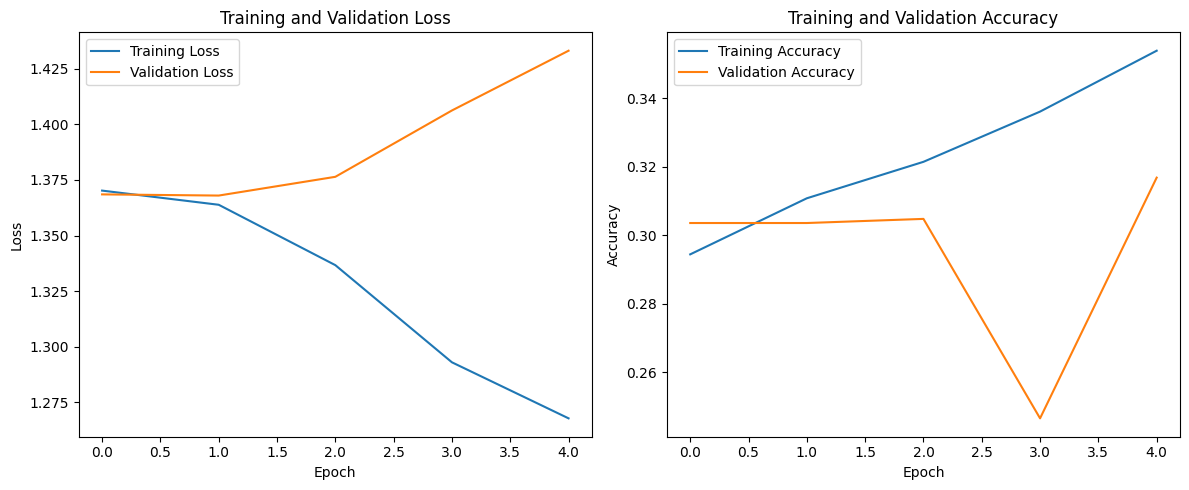

In [ ]:
from sklearn.metrics import classification_report
import numpy as np
import matplotlib.pyplot as plt

# 1. Evaluate the trained model on the validation data
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

# 2. Obtain the model's predictions on the validation set
y_pred_probs = model.predict(X_val)

# 3. Convert one-hot encoded true labels and predicted probabilities to class labels
y_true_labels = np.argmax(y_val, axis=1)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

# Get class names from the label_encoder used earlier
class_names = label_encoder.classes_

# 5. Generate and print a classification report
print("\nClassification Report:")
print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))

# Plotting training and validation loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

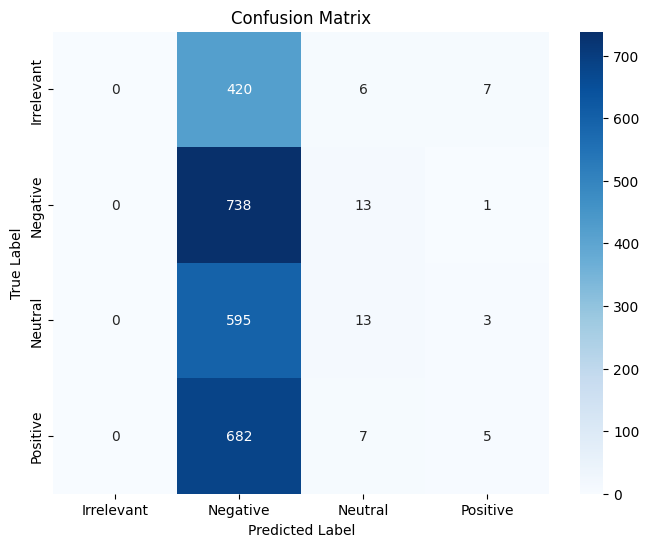

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute the confusion matrix
cm = confusion_matrix(y_true_labels, y_pred_labels)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

Explanation of Performance:

1. Severe Class Imbalance and Defaulting to Majority Class:

Observation from Classification Report and Confusion Matrix: The most striking issue is the model's heavy bias towards predicting the 'Negative' sentiment. The classification report shows very high recall for 'Negative' (0.98), but extremely low precision, meaning it's classifying almost everything as 'Negative'. Conversely, 'Irrelevant', 'Neutral', and 'Positive' classes have near-zero precision, recall, and f1-scores. The confusion matrix explicitly confirms this: nearly all true 'Irrelevant', 'Neutral', and 'Positive' samples are being misclassified as 'Negative'.
Reason: Your dataset has an imbalance in sentiment distribution (Negative: 3757, Positive: 3472, Neutral: 3053, Irrelevant: 2165). The model is essentially learning that the safest bet to minimize overall error (loss) is to predict the most frequent class, as this strategy still yields a 30% accuracy, which is what we are seeing.
2. Lack of Effective Learning:

Observation from Training History: The training and validation loss and accuracy curves (which you can see in the plots from cell b85bac43) show that the model is barely learning anything meaningful. The validation accuracy hovers around 30-31% from the very first epoch, and EarlyStopping triggered quickly because the validation loss wasn't improving. This indicates the model isn't picking up on subtle patterns to distinguish between classes.
Next Steps to Improve Performance:

To address these fundamental issues, I recommend focusing on the following:

Address Class Imbalance: This is critical. You can tackle this by:

Class Weighting: Assign higher weights to under-represented classes during model training. Keras' model.fit() method accepts a class_weight argument.
Resampling Techniques: Over-sampling the minority classes (e.g., using SMOTE) or under-sampling the majority classes. Be cautious with under-sampling as it can lead to loss of information.
Utilize Pre-trained Word Embeddings: Instead of learning embeddings from scratch with your limited dataset, using pre-trained embeddings (like Word2Vec, GloVe, or FastText) can provide a significant boost. These embeddings capture rich semantic relationships from much larger corpuses and can help your model understand the nuances of words more effectively.

Hyperparameter Tuning (Revisit): After addressing imbalance and potentially using pre-trained embeddings, we can revisit more advanced hyperparameter tuning (e.g., learning rate schedules, different optimizers, more GRU units, different dropout rates, or even increasing the patience for EarlyStopping).

I suggest we start by implementing class weighting and/or exploring the integration of pre-trained word embeddings. Which approach would you like to try first?